In [6]:
import re
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.feature_selection import SelectKBest, chi2

sns.set(style="whitegrid")

DATA_PATH = "/content/ai_human_detection_v1.csv"   # change if needed

In [7]:
df_raw = pd.read_csv(DATA_PATH)
print("Shape:", df_raw.shape)
print(df_raw["human_or_ai"].value_counts())

Shape: (686, 11)
human_or_ai
ai                335
human             181
post_edited_ai    170
Name: count, dtype: int64


In [8]:
VALID_LABELS = {"human", "ai", "post_edited_ai"}

def clean_dataset(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["text"] = df["text"].astype(str)

    # Remove garbage rows
    error_mask = df["text"].str.startswith("Error:", na=False) | df["text"].str.contains("Client Error", na=False)
    df = df[~error_mask].copy()

    # Remove empty/very short text
    df = df[df["text"].str.strip().str.len() >= 10].copy()

    # Keep only valid labels
    df = df[df["human_or_ai"].isin(VALID_LABELS)].copy()

    # Drop duplicates
    df = df.drop_duplicates()

    return df

df = clean_dataset(df_raw)
print("Cleaned shape:", df.shape)
print(df["human_or_ai"].value_counts())

Cleaned shape: (680, 11)
human_or_ai
ai                333
human             181
post_edited_ai    166
Name: count, dtype: int64


In [9]:
def add_engineered_features(df_in: pd.DataFrame, peak_rule: str = "business_hours") -> pd.DataFrame:
    """
    Adds engineered features to help predict the label (human_or_ai).
    peak_rule changes how is_peak_hour is defined (Task 2).
    """
    df_out = df_in.copy()

    # --- generation_date -> hour (if available) ---
    if "generation_date" in df_out.columns:
        df_out["generation_date"] = pd.to_datetime(df_out["generation_date"], errors="coerce")
        df_out["hour"] = df_out["generation_date"].dt.hour
    else:
        df_out["hour"] = np.nan

    # --- basic text stats ---
    text = df_out["text"].astype(str)
    df_out["char_len"] = text.str.len()
    df_out["word_len"] = text.str.split().apply(len)
    df_out["punct_count"] = text.apply(lambda t: sum(ch in string.punctuation for ch in t))

    # ✅ Task 1: new engineered feature (punctuation density)
    # Normalizes punctuation by length so it’s not just “longer text => more punctuation”.
    df_out["punct_ratio"] = df_out["punct_count"] / df_out["char_len"].replace(0, np.nan)
    df_out["punct_ratio"] = df_out["punct_ratio"].fillna(0.0)

    # ✅ Task 2: is_peak_hour rule variations
    h = df_out["hour"].fillna(-1)  # NaT -> -1 so it becomes non-peak
    if peak_rule == "business_hours":
        df_out["is_peak_hour"] = ((h >= 9) & (h <= 17)).astype(int)
    elif peak_rule == "evening":
        df_out["is_peak_hour"] = ((h >= 18) & (h <= 23)).astype(int)
    elif peak_rule == "night":
        df_out["is_peak_hour"] = ((h >= 0) & (h <= 5)).astype(int)
    else:
        raise ValueError("peak_rule must be: business_hours, evening, night")

    return df_out


def build_pipeline(top_k: int, use_feature_selection: bool = False) -> Pipeline:
    """
    Builds the modeling pipeline:
    - text -> TF-IDF char ngrams (max_features = top_k)   [Task 3]
    - numeric engineered features -> scaled
    - classifier -> multinomial Logistic Regression
    - optional SelectKBest on text TF-IDF only            [Task 4]
    """
    numeric_features = ["char_len", "word_len", "punct_count", "punct_ratio", "is_peak_hour"]

    # TF-IDF on character ngrams works well across languages and captures style cues
    base_vec = TfidfVectorizer(
        analyzer="char_wb",
        ngram_range=(3, 5),
        min_df=2,
        max_df=0.95,
        strip_accents="unicode",
        max_features=top_k
    )

    # Optional feature selection: chi2 requires non-negative features.
    # TF-IDF is non-negative, so we apply SelectKBest ONLY inside the text pipeline.
    if use_feature_selection:
        text_transform = Pipeline([
            ("tfidf", base_vec),
            ("select", SelectKBest(score_func=chi2, k=min(2000, top_k)))  # choose up to 2000 best text features
        ])
    else:
        text_transform = base_vec

    preprocess = ColumnTransformer(
        transformers=[
            ("text", text_transform, "text"),
            ("num", StandardScaler(with_mean=False), numeric_features),
        ],
        remainder="drop"
    )

    clf = LogisticRegression(
        max_iter=3000,
        solver="saga",
        multi_class="multinomial",
        class_weight="balanced",
        n_jobs=-1
    )

    return Pipeline([
        ("preprocess", preprocess),
        ("clf", clf)
    ])


def evaluate_pipeline(df_features: pd.DataFrame, title: str, pipeline: Pipeline):
    """
    Splits -> trains -> evaluates.
    Prints accuracy + report + confusion matrix.
    Returns fitted model and split outputs for comparisons.
    """
    # Only columns needed by the pipeline
    X = df_features[["text", "char_len", "word_len", "punct_count", "punct_ratio", "is_peak_hour"]].copy()
    y = df_features["human_or_ai"].copy()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    pipeline.fit(X_train, y_train)
    pred = pipeline.predict(X_test)

    acc = accuracy_score(y_test, pred)

    print(f"\n===== {title} =====")
    print("Accuracy:", round(acc, 4))
    print("\nClassification report:\n", classification_report(y_test, pred, digits=3))

    cm = confusion_matrix(y_test, pred, labels=pipeline.named_steps["clf"].classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=pipeline.named_steps["clf"].classes_)
    disp.plot(values_format="d")
    plt.title(f"Confusion Matrix - {title}")
    plt.show()

    return pipeline, acc, X_test, y_test, pred


def show_top_text_features(fitted_pipeline: Pipeline, top_n: int = 15):
    """
    “Top feature importances” for text using Logistic Regression coefficients.
    We rank by average absolute coefficient magnitude across classes.
    """
    preprocess = fitted_pipeline.named_steps["preprocess"]
    clf = fitted_pipeline.named_steps["clf"]

    text_transformer = preprocess.named_transformers_["text"]
    if isinstance(text_transformer, Pipeline):
        vec = text_transformer.named_steps["tfidf"]
    else:
        vec = text_transformer

    feature_names = vec.get_feature_names_out()
    n_text = len(feature_names)

    coef = clf.coef_[:, :n_text]                 # slice to text features
    importance = np.mean(np.abs(coef), axis=0)   # avg abs weight across classes

    top_idx = np.argsort(importance)[-top_n:][::-1]
    print("\nTop text features (avg |coef| across classes):")
    for i in top_idx:
        print(f"{feature_names[i]!r}: {importance[i]:.6f}")

Engineered features preview:
   char_len  word_len  punct_count  punct_ratio  is_peak_hour
0       208        34            5     0.024038             0
3      4219       558          137     0.032472             0
4       810       147           21     0.025926             0
5       316        57            4     0.012658             0
6       134        24            0     0.000000             0


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



===== Task 1 Baseline (top_k=3000, business_hours) =====
Accuracy: 1.0

Classification report:
                 precision    recall  f1-score   support

            ai      1.000     1.000     1.000        67
         human      1.000     1.000     1.000        36
post_edited_ai      1.000     1.000     1.000        33

      accuracy                          1.000       136
     macro avg      1.000     1.000     1.000       136
  weighted avg      1.000     1.000     1.000       136



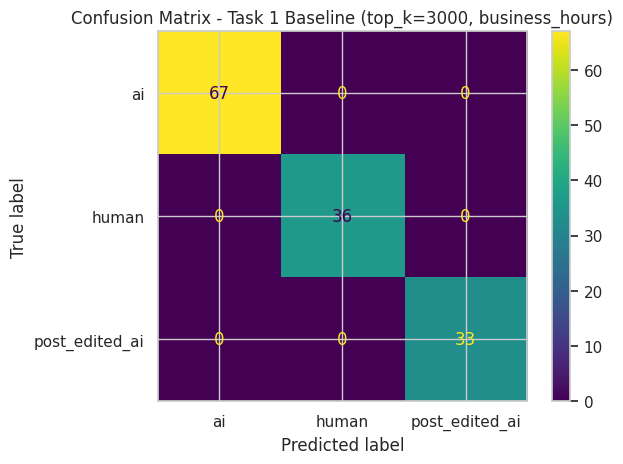


Top text features (avg |coef| across classes):
' . ': 0.719883
' ال': 0.271635
'es ': 0.184637
'يد ': 0.183282
' th': 0.178153
' कि': 0.167512
' re': 0.163863
'ss ': 0.163061
'ैं ': 0.159950
'os ': 0.158289
'is ': 0.151028
'on ': 0.147320
'er ': 0.147032
'nt ': 0.141496
'end': 0.136258


In [10]:
# Task 1: baseline run (top_k=3000) with engineered features
df_t1 = add_engineered_features(df, peak_rule="business_hours")

print("Engineered features preview:")
print(df_t1[["char_len", "word_len", "punct_count", "punct_ratio", "is_peak_hour"]].head())

pipe_t1 = build_pipeline(top_k=3000, use_feature_selection=False)
fit_t1, acc_t1, _, _, _ = evaluate_pipeline(df_t1, "Task 1 Baseline (top_k=3000, business_hours)", pipe_t1)

show_top_text_features(fit_t1, top_n=15)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



===== Task 2 Peak Rule = business_hours =====
Accuracy: 1.0

Classification report:
                 precision    recall  f1-score   support

            ai      1.000     1.000     1.000        67
         human      1.000     1.000     1.000        36
post_edited_ai      1.000     1.000     1.000        33

      accuracy                          1.000       136
     macro avg      1.000     1.000     1.000       136
  weighted avg      1.000     1.000     1.000       136



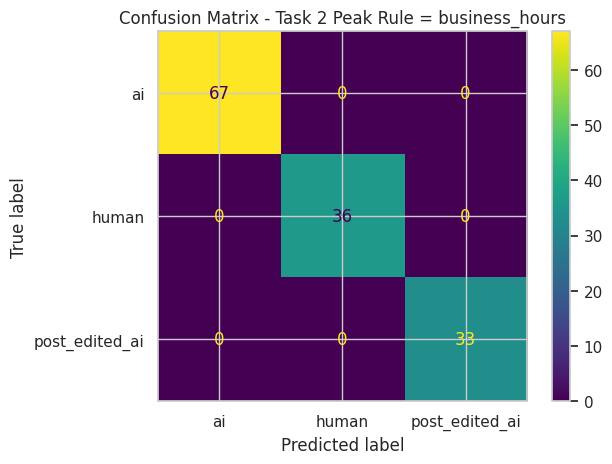

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



===== Task 2 Peak Rule = evening =====
Accuracy: 0.7353

Classification report:
                 precision    recall  f1-score   support

            ai      0.750     0.716     0.733        67
         human      0.973     1.000     0.986        36
post_edited_ai      0.457     0.485     0.471        33

      accuracy                          0.735       136
     macro avg      0.727     0.734     0.730       136
  weighted avg      0.738     0.735     0.736       136



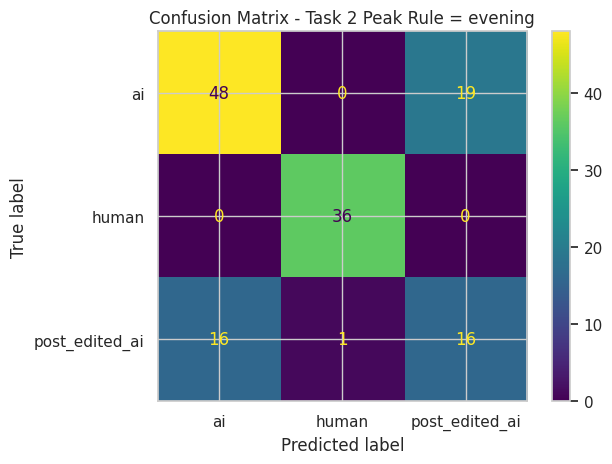

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



===== Task 2 Peak Rule = night =====
Accuracy: 0.7353

Classification report:
                 precision    recall  f1-score   support

            ai      0.750     0.716     0.733        67
         human      0.973     1.000     0.986        36
post_edited_ai      0.457     0.485     0.471        33

      accuracy                          0.735       136
     macro avg      0.727     0.734     0.730       136
  weighted avg      0.738     0.735     0.736       136



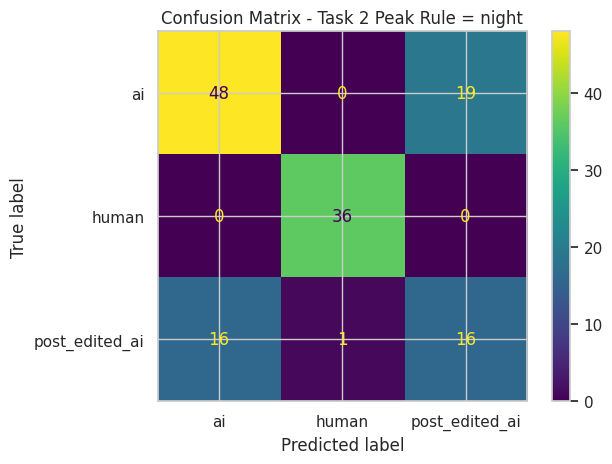


Task 2 Summary (Accuracy by peak rule):
business_hours  -> 1.0000
evening         -> 0.7353
night           -> 0.7353


In [11]:
# Task 2: compare peak hour rules
rules = ["business_hours", "evening", "night"]
task2_results = []

for rule in rules:
    df_rule = add_engineered_features(df, peak_rule=rule)
    pipe_rule = build_pipeline(top_k=3000, use_feature_selection=False)
    _, acc, _, _, _ = evaluate_pipeline(df_rule, f"Task 2 Peak Rule = {rule}", pipe_rule)
    task2_results.append((rule, acc))

print("\nTask 2 Summary (Accuracy by peak rule):")
for rule, acc in task2_results:
    print(f"{rule:15s} -> {acc:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



===== Task 3 top_k=10 =====
Accuracy: 0.9926

Classification report:
                 precision    recall  f1-score   support

            ai      1.000     0.985     0.992        67
         human      0.973     1.000     0.986        36
post_edited_ai      1.000     1.000     1.000        33

      accuracy                          0.993       136
     macro avg      0.991     0.995     0.993       136
  weighted avg      0.993     0.993     0.993       136



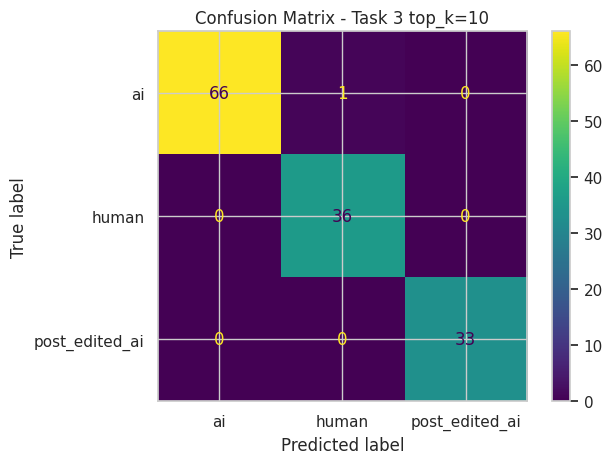


Top features for top_k=10:

Top text features (avg |coef| across classes):
' th': 0.434783
' an': 0.310831
'ion': 0.184434
'ing': 0.184238
' **': 0.179954
'nd ': 0.111166
' and': 0.057123
'and': 0.030486
'the': 0.020236
'and ': 0.015266


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



===== Task 3 top_k=30 =====
Accuracy: 0.9926

Classification report:
                 precision    recall  f1-score   support

            ai      1.000     0.985     0.992        67
         human      0.973     1.000     0.986        36
post_edited_ai      1.000     1.000     1.000        33

      accuracy                          0.993       136
     macro avg      0.991     0.995     0.993       136
  weighted avg      0.993     0.993     0.993       136



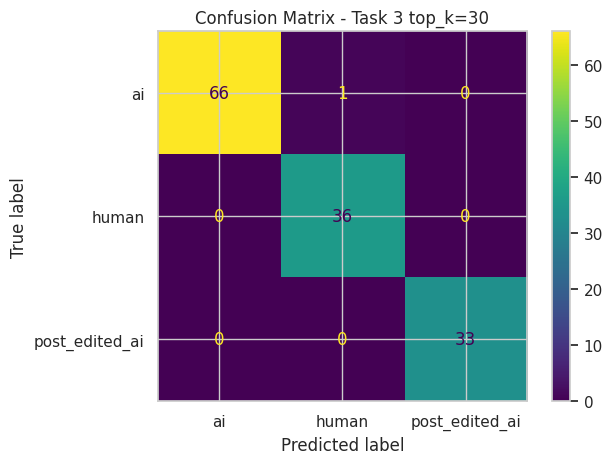


Top features for top_k=30:

Top text features (avg |coef| across classes):
'on ': 0.406043
'es ': 0.391522
' th': 0.365678
' re': 0.289838
' de': 0.283837
' ال': 0.242708
' an': 0.240815
'tion': 0.240492
'tio': 0.236963
'ing ': 0.204569


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



===== Task 3 top_k=50 =====
Accuracy: 0.9926

Classification report:
                 precision    recall  f1-score   support

            ai      1.000     0.985     0.992        67
         human      0.973     1.000     0.986        36
post_edited_ai      1.000     1.000     1.000        33

      accuracy                          0.993       136
     macro avg      0.991     0.995     0.993       136
  weighted avg      0.993     0.993     0.993       136



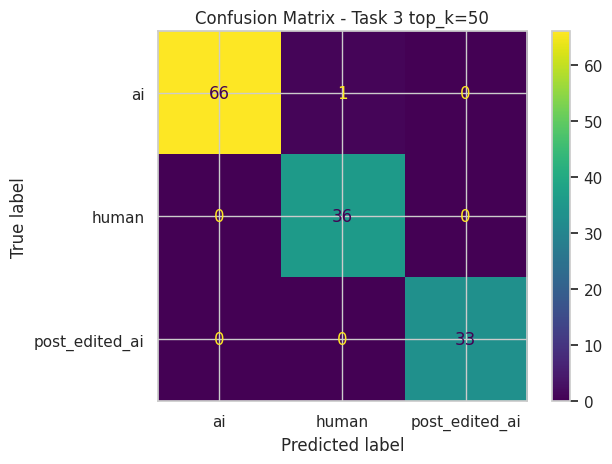


Top features for top_k=50:

Top text features (avg |coef| across classes):
'er ': 0.429305
'es ': 0.344406
'on ': 0.337564
'in ': 0.312241
' th': 0.282301
' ال': 0.237194
' re': 0.236981
'ent': 0.213588
'tion': 0.204325
'tio': 0.201294


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



===== Task 3 top_k=1000 =====
Accuracy: 1.0

Classification report:
                 precision    recall  f1-score   support

            ai      1.000     1.000     1.000        67
         human      1.000     1.000     1.000        36
post_edited_ai      1.000     1.000     1.000        33

      accuracy                          1.000       136
     macro avg      1.000     1.000     1.000       136
  weighted avg      1.000     1.000     1.000       136



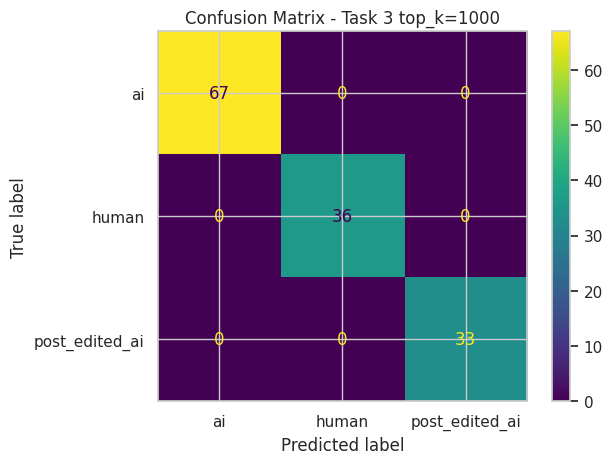


Top features for top_k=1000:

Top text features (avg |coef| across classes):
' ال': 0.415409
'es ': 0.260541
'os ': 0.257009
'ss ': 0.245465
' re': 0.226946
' th': 0.224305
'on ': 0.223196
'er ': 0.203016
'is ': 0.202661
'end': 0.201513


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



===== Task 3 top_k=3000 =====
Accuracy: 1.0

Classification report:
                 precision    recall  f1-score   support

            ai      1.000     1.000     1.000        67
         human      1.000     1.000     1.000        36
post_edited_ai      1.000     1.000     1.000        33

      accuracy                          1.000       136
     macro avg      1.000     1.000     1.000       136
  weighted avg      1.000     1.000     1.000       136



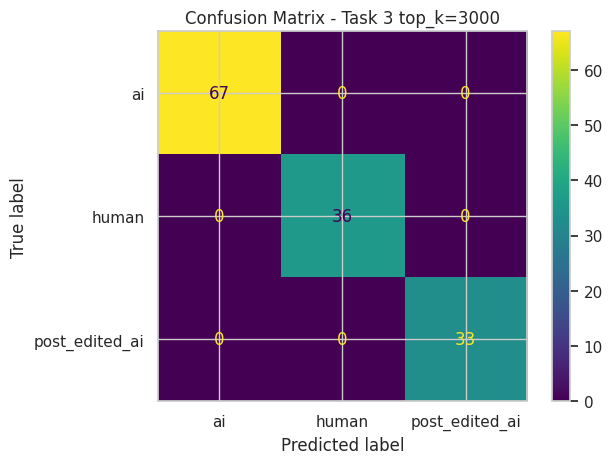


Top features for top_k=3000:

Top text features (avg |coef| across classes):
' . ': 0.719378
' ال': 0.271145
'es ': 0.184388
'يد ': 0.183245
' th': 0.177963
' कि': 0.167527
' re': 0.163649
'ss ': 0.162941
'ैं ': 0.159973
'os ': 0.158029


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



===== Task 3 top_k=5000 =====
Accuracy: 1.0

Classification report:
                 precision    recall  f1-score   support

            ai      1.000     1.000     1.000        67
         human      1.000     1.000     1.000        36
post_edited_ai      1.000     1.000     1.000        33

      accuracy                          1.000       136
     macro avg      1.000     1.000     1.000       136
  weighted avg      1.000     1.000     1.000       136



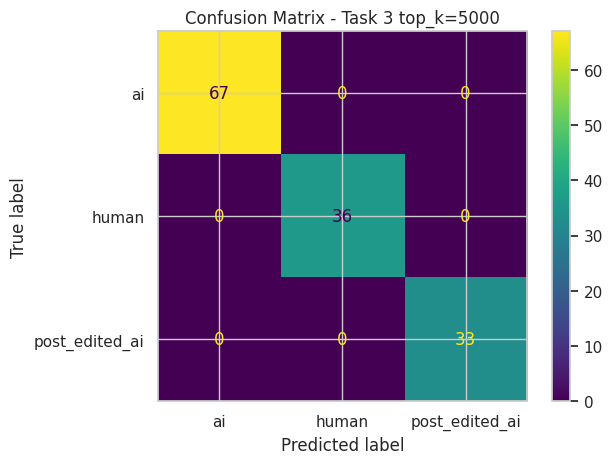


Top features for top_k=5000:

Top text features (avg |coef| across classes):
' . ': 0.659101
' ال': 0.225160
' th': 0.161444
'يد ': 0.161435
'es ': 0.161095
' कि': 0.142068
' re': 0.141828
'da ': 0.139048
'os ': 0.134646
'is ': 0.133541

Task 3 Accuracy Summary:
top_k=   10 -> accuracy=0.9926
top_k=   30 -> accuracy=0.9926
top_k=   50 -> accuracy=0.9926
top_k= 1000 -> accuracy=1.0000
top_k= 3000 -> accuracy=1.0000
top_k= 5000 -> accuracy=1.0000


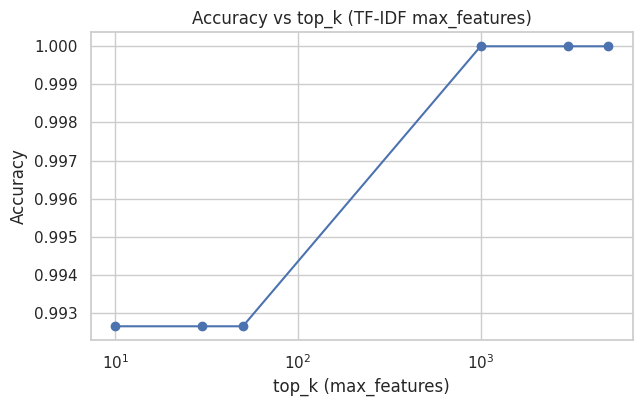

In [12]:
# Task 3: vary top_k (max_features) and compare accuracy + top features
df_t3 = add_engineered_features(df, peak_rule="business_hours")

topk_values = [10, 30, 50, 1000, 3000, 5000]
task3_results = []

for k in topk_values:
    pipe_k = build_pipeline(top_k=k, use_feature_selection=False)
    fit_k, acc, _, _, _ = evaluate_pipeline(df_t3, f"Task 3 top_k={k}", pipe_k)
    task3_results.append((k, acc))

    print(f"\nTop features for top_k={k}:")
    show_top_text_features(fit_k, top_n=10)

print("\nTask 3 Accuracy Summary:")
for k, acc in task3_results:
    print(f"top_k={k:5d} -> accuracy={acc:.4f}")

plt.figure(figsize=(7,4))
plt.plot([k for k,_ in task3_results], [acc for _,acc in task3_results], marker="o")
plt.xscale("symlog")
plt.title("Accuracy vs top_k (TF-IDF max_features)")
plt.xlabel("top_k (max_features)")
plt.ylabel("Accuracy")
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



===== Task 4 Baseline (No FS, top_k=3000) =====
Accuracy: 1.0

Classification report:
                 precision    recall  f1-score   support

            ai      1.000     1.000     1.000        67
         human      1.000     1.000     1.000        36
post_edited_ai      1.000     1.000     1.000        33

      accuracy                          1.000       136
     macro avg      1.000     1.000     1.000       136
  weighted avg      1.000     1.000     1.000       136



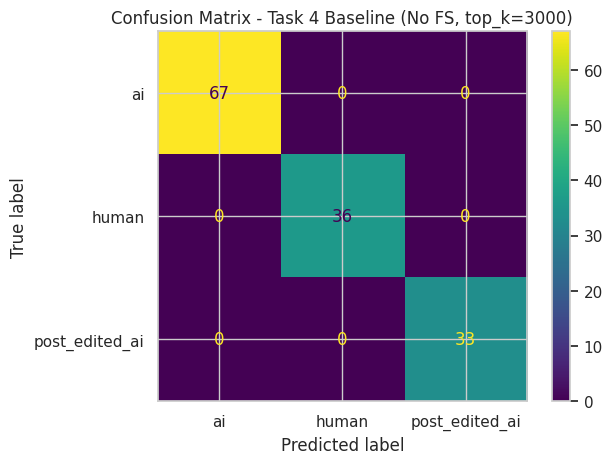

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



===== Task 4 With Feature Selection (SelectKBest) =====
Accuracy: 1.0

Classification report:
                 precision    recall  f1-score   support

            ai      1.000     1.000     1.000        67
         human      1.000     1.000     1.000        36
post_edited_ai      1.000     1.000     1.000        33

      accuracy                          1.000       136
     macro avg      1.000     1.000     1.000       136
  weighted avg      1.000     1.000     1.000       136



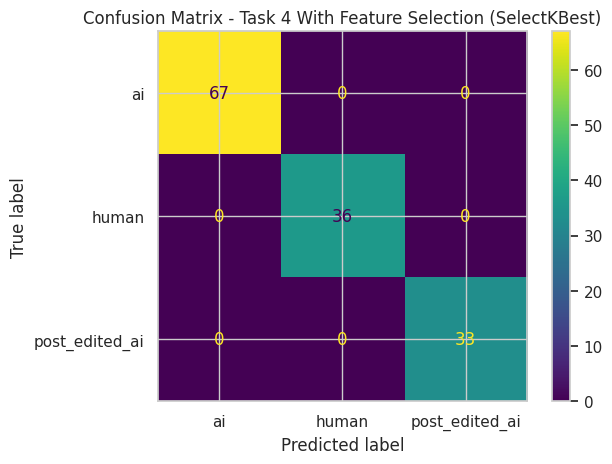


Task 4 Comparison:
Baseline accuracy: 1.0
FS accuracy      : 1.0

Top features (Baseline):

Top text features (avg |coef| across classes):
' . ': 0.721954
' ال': 0.273773
'es ': 0.185683
'يد ': 0.183324
' th': 0.178960
' कि': 0.167284
' re': 0.164770
'ss ': 0.163571
'ैं ': 0.159633
'os ': 0.159397
'is ': 0.151426
'on ': 0.147932
'er ': 0.147466
'nt ': 0.141984
'end': 0.136690

Top features (With FS):

Top text features (avg |coef| across classes):
'ons, ': 1.819822
'ons': 0.981617
'onomi': 0.791541
' . ': 0.730804
'ons ': 0.673809
'ons,': 0.610527
' not': 0.214289
' les ': 0.204162
'ast': 0.194429
' into': 0.177357
' sp': 0.171852
'dep': 0.171567
'onn': 0.167044
'iye ': 0.164141
'fec': 0.162526


In [13]:
# Task 4: Feature selection (SelectKBest on text TF-IDF only)
df_t4 = add_engineered_features(df, peak_rule="business_hours")

# Baseline (no feature selection)
pipe_base = build_pipeline(top_k=3000, use_feature_selection=False)
fit_base, acc_base, _, _, _ = evaluate_pipeline(df_t4, "Task 4 Baseline (No FS, top_k=3000)", pipe_base)

# With feature selection
pipe_fs = build_pipeline(top_k=3000, use_feature_selection=True)
fit_fs, acc_fs, _, _, _ = evaluate_pipeline(df_t4, "Task 4 With Feature Selection (SelectKBest)", pipe_fs)

print("\nTask 4 Comparison:")
print("Baseline accuracy:", round(acc_base, 4))
print("FS accuracy      :", round(acc_fs, 4))

print("\nTop features (Baseline):")
show_top_text_features(fit_base, top_n=15)

print("\nTop features (With FS):")
show_top_text_features(fit_fs, top_n=15)